### Spatial features of measles transmission in England and Wales during the pre-vaccine era
In this notebook, we will move away from theoretical results and aim to model a famous observational dataset in disease transmission - records of measles cases in England and Wales during the pre-vaccine era.  This is a dataset that has been modeled in a number of famous publications and used to demonstrate phenomena like switching from annual to biennial epidemics in the face of demographic changes, traveling wave-like behavior from cities to smaller population centers around them, and disease extinction in sub-CCS populations followed by reimportation from elsewhere.  Here, we will aim to reproduce two of these results in a single spatial model - the demonstration of traveling waves of infection from [Grenfell BT, Bjørnstad ON, Kappey J. _Travelling waves and spatial hierarchies in measles epidemics._ Nature. 2001 Dec 13;414(6865):716-23](https://www.nature.com/articles/414716a), and the interplay between exinction and reimportation vs. population size from [Conlan AJ et al. _Resolving the impact of waiting time distributions on the persistence of measles._ J R Soc Interface. 2010 Apr 6;7(45):623-40](https://pmc.ncbi.nlm.nih.gov/articles/PMC2842776/).

This notebook will also demonstrate construction of a spatial population scenario representing real populations, rather than the grids used up until now.  This dataset also covers a period of time with important dynamics in birth and deaths rates, that produce their own interesting impacts on measles dynamics, but for now we will model constant birth and death rates as the phenomena we seek to reproduce are driven more by spatial connections between populations.  In the future, we will return to this scenario and also use this to demonstrate for users how to set up spatiotemporally varying demographics from existing datasets.

In [24]:
import numpy as np
import pandas as pd
import numba as nb
import os
import sys
from laser.core.propertyset import PropertySet
import laser.core.distributions as dists
from laser.core.demographics import AliasedDistribution
from laser.core.demographics import KaplanMeierEstimator
from laser.generic import SEIR
from laser.generic import Model
from laser.generic.newutils import ValuesMap
from laser.generic.vitaldynamics import BirthsByCBR, MortalityByEstimator
from laser.core.migration import gravity
from laser.core.migration import row_normalizer

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pywt


import laser.core
import laser.generic

data_dir = os.path.join('..', '..', '..', "data")
sys.path.append(data_dir)

from EnglandWalesmeasles import data as engwal
distances = np.load(os.path.join("..", "..", "..", "data", "EnglandWalesdistances.npy"))

print(f"{np.__version__=}")
print(f"{laser.core.__version__=}")
print(f"{laser.generic.__version__=}")


np.__version__='2.3.5'
laser.core.__version__='0.7.0'
laser.generic.__version__='0.0.0'


In [25]:
class Importation:
    def __init__(self, model, infdurdist, infdurmin: int =1, period: int = 30, count: int = 3, end_tick: int = 10*365):
        self.model = model
        self.infdurdist = infdurdist
        self.infdurmin = infdurmin
        self.period = period
        self.count = count
        self.end_tick = end_tick if end_tick is not None else model.params.nticks

        self.model.nodes.add_vector_property("imports", model.params.nticks + 1, dtype=np.uint32, default=0)

        return
    
    def step(self, tick: int) -> None:
        if tick > 0 and tick % self.period == 0 and tick < self.end_tick:
            i_susceptible = np.nonzero(self.model.people.state == SEIR.State.SUSCEPTIBLE.value)[0]
            if len(i_susceptible) > 0:
                count = min(self.count, len(i_susceptible))
                i_infect = np.random.choice(i_susceptible, size=count, replace=False)
                self.model.people.state[i_infect] = SEIR.State.INFECTIOUS.value
                samples = dists.sample_floats(self.infdurdist, np.zeros(count, np.float32))
                samples = np.round(samples)
                samples = np.maximum(samples, self.infdurmin).astype(self.model.people.itimer.dtype)
                self.model.people.itimer[i_infect] = samples
                inf_by_node = np.bincount(self.model.people.nodeid[i_infect], minlength=len(self.model.nodes)).astype(self.model.nodes.S.dtype)
                self.model.nodes.S[tick + 1] -= inf_by_node
                self.model.nodes.I[tick + 1] += inf_by_node
                self.model.nodes.imports[tick] = inf_by_node
            # else:
            #     print(f"No susceptibles to infect at tick {tick}")

        return

class SeasonalTransmission(SEIR.Transmission):
        
    def step(self, tick: int) -> None:
        ft = self.model.nodes.forces[tick]

        N = self.model.nodes.S[tick] + self.model.nodes.E[tick] + (I := self.model.nodes.I[tick])  # noqa: E741
        # Might have R
        if hasattr(self.model.nodes, "R"):
            N += self.model.nodes.R[tick]

        ft[:] = self.model.params.beta * I / N * self.model.params.beta_season[tick % 365]
        transfer = ft[:, None] * self.model.network
        ft += transfer.sum(axis=0)
        ft -= transfer.sum(axis=1)
        ft = -np.expm1(-ft)  # Convert to probability of infection

        newly_infected_by_node = np.zeros((nb.get_num_threads(), self.model.nodes.count), dtype=np.int32)
        self.nb_transmission_step(
            self.model.people.state,
            self.model.people.nodeid,
            ft,
            newly_infected_by_node,
            self.model.people.etimer,
            self.expdurdist,
            self.expdurmin,
            tick,
        )
        newly_infected_by_node = newly_infected_by_node.sum(axis=0).astype(self.model.nodes.S.dtype)  # Sum over threads

        # state(t+1) = state(t) + ∆state(t)
        self.model.nodes.S[tick + 1] -= newly_infected_by_node
        self.model.nodes.E[tick + 1] += newly_infected_by_node
        # Record today's ∆
        self.model.nodes.newly_infected[tick] = newly_infected_by_node

        return

In [26]:
# See ../../../data/readme.md for a description of the England and Wales measles data contained there.  
# We provide pre-computed pairwise distances between the population centers in EnglandWalesdistances.npy.
# Here, we compute a population-wide average crude birth rate (CBR) for England and Wales from the data.

average_pop = np.array([np.mean(place.population) for place in engwal.places.values()])
average_birthrate = np.array([np.mean(place.births/place.population) for place in engwal.places.values()])
average_cbr = 1000*np.sum(average_pop*average_birthrate)/np.sum(average_pop)
birthrates = np.array([place.births/place.population *1000 for place in engwal.places.values()])

In [27]:
# Define the geodataframe
cells = []
for placename, place in engwal.places.items():
    lat, long = place.latitude, place.longitude
    nodeid = engwal.placenames.index(placename)
    name = placename
    # As long as we are here, record the proportion of weeks with zero cases.  
    # Wavelet analysis is more complex and we will come back to that later.
    prop_zero = np.mean(np.array(place.cases) == 0)

    cells.append({"nodeid": nodeid, "name": name, "population": place.population[0], "geometry": Point(long, lat), "prop_zero": prop_zero})

scenario = gpd.GeoDataFrame(cells, columns=["nodeid", "name", "population", "geometry", "prop_zero"], crs="EPSG:4326")

In [28]:
run_sims = True
start_from_last = False


### Calibration
In order to reproduce the fadeout/reimportation phenomenon and the travelling wave dynamics observed in the measles dataset, we will have to undergo a calibration exercise - the model will not faithfully reproduce all of the details of the data for any set of input parameters.  We are faced with a fairly large parameter space to deal with - exposed/infectious periods, infectivity, amplitude and shape of seasonal forcing in infectivity, and the migration network between populations.  For the purposes of this demonstration, we will leverage existing knowledge of the biology of measles and past analyses of this data to restrict our priors and get to a place where we should be able to produce reasonable results with order 100 simulations - manageable for a powerful laptop in order hours, or in a matter of minutes on a HPC cluster.

We will choose distributions that put the exposed and infectious periods at 10 and 8 days long, respectively, with a std. deviation of a couple of days each.  

The work in Bjørnstad, O.N., Finkenstädt, B.F. and Grenfell, B.T. (2002), _Dynamics of Measles Epidemics: Estimating Scaling of Transmission Rates Using a Time Series SIR Model_. Ecological Monographs, 72: 169-184 explores inferring the transmission rates.  In the discussion section, they find that under the assumption of homogenous mixing within spatial units (as in our model), $R_0$ is on average equal to approximately 30 and varies throughout the year, with a minimum of around 19 and a maximum around 40.  So in our calibration exercise, we will take values in this vinicity, and use the seasonal forcing profile estimated in that work.

Other sources and some intuition can help constrain the search space for the migration model parameters.  To keep things simple, we will use a gravity model with 4 parameters

$$
M_{i,j} = k \frac{p_i^a p_j^b}{d^c}
$$

Our work with the 2-patch SIR system revealed that there is roughly 2 orders of magnitude in overall coupling in which "interesting" stuff happens (i.e., the system is not totally decoupled and also not fully synchronized), between about 0.001 and 0.1.  We can extrapolate from this and explore values of $k$ such that the average node is exporting a fraction of its infectivity in this range.   Prior study of the time between fadeout and reimportation has found that the importation rate into a node seems to scale like the square root of the node population (see Keeling & Rohani, ref appropriately here), so we will explore values of $b$ in the vicinity of 0.5.  As to $a$, we'll assume that there's no "self-gravity" here and set this to zero - that is, a person's propensity to travel to other places is independent of the population of their home and determined entirely by the distance to and population of potential destinations.  Finally, w/r/t $c$, we'll assume that the difficulty of traveling somewhere is at least linear in distance and explore values from 1 to 2.

In [29]:

output_file = os.path.join("outputs", "EW_outputs.npy")
params_file = os.path.join("outputs", "EW_parameter_samples.csv")
nsims = 150
nticks = 40*365
npatches = len(scenario)
if run_sims:
    istart = 0
    if start_from_last and (os.path.exists(output_file) 
                            and os.path.exists(params_file)):
        
        outputs =np.load(output_file)
        while istart < outputs.shape[0] and np.any(outputs[istart]):
            istart += 1
        params_df = pd.read_csv(params_file)
        beta_samples = params_df["beta"].values
        amplitude_samples = params_df["amplitude"].values
        k_samples = params_df["k"].values
        b_samples = params_df["b"].values
        c_samples = params_df["c"].values
    else:
        
        beta_samples = np.random.uniform(3, 4.5, nsims) #Ro from 24 to 36
        amplitude_samples = np.random.uniform(0.5, 1.5, nsims) #1 will be exactly the seasonal forcing profile from reference above
        k_samples = 10 ** np.random.uniform(-3.5, -1, nsims)
        #a_samples = np.random.uniform(-0.5, 0.5, nsims)
        b_samples = np.random.uniform(0.25, 1.0, nsims)
        c_samples = np.random.uniform(1, 2, nsims)
        params_df = pd.DataFrame({
            "beta": beta_samples,
            "amplitude": amplitude_samples,
            "k": k_samples,
            "b": b_samples,
            "c": c_samples
        })
        params_df.to_csv(params_file, index=False)
        outputs = np.zeros((nsims, (nticks+1) // 7, npatches), dtype=np.uint32)
    
    log_betas = np.array([0.155, 0.571, 0.46, 0.34, 0.30, 0.34, 0.24, 0.15, 0.31, 0.40, 0.323, 0.238, 0.202, 0.203, 0.074,
        -0.095, -0.218, -0.031, 0.433, 0.531, 0.479, 0.397, 0.444, 0.411, 0.291, 0.509])
    beta_season = np.repeat(log_betas, np.floor(365 / len(log_betas)).astype(int))
    beta_season = np.append(beta_season, beta_season[-1])
    beta_season = np.exp( (beta_season - np.mean(beta_season)) )

    for i in range(istart, nsims):
        print(f"Running simulation {i+1} of {nsims}...")
        parameters = PropertySet(
            {"seed": 4, "nticks": nticks,
            "exp_shape": 40, "exp_scale": 0.25,
            "verbose": True, "beta": beta_samples[i], "inf_mean": 8, "inf_sigma": 2, "cbr": average_cbr,
            "beta_season": beta_season**amplitude_samples[i],
            "importation_period": 30, "importation_count": 3, "importation_start": 1, "importation_end": 10*365,
            "gravity_k": k_samples[i], "gravity_b": b_samples[i], "gravity_c": c_samples[i],
            "skip_capacity": False, "capacity_safety_factor": 3.0}
        )

        scenario["E"] = 0
        scenario["I"] = 3
        scenario["R"] = np.round(0.95 * scenario.population).astype(np.uint32)
        scenario["S"] = scenario.population - scenario["E"] - scenario["I"] - scenario["R"]

        expdist = dists.gamma(shape=parameters.exp_shape, scale=parameters.exp_scale)
        infdist = dists.normal(loc=parameters.inf_mean, scale=parameters.inf_sigma)

        birthrate_map = ValuesMap.from_scalar(parameters.cbr, nnodes=len(scenario), nsteps=parameters.nticks)
        rate_const = 365 * ((1 + parameters.cbr / 1000) ** (1/365) - 1) # approximate annual to daily
        stable_age_dist = np.array(1000*np.exp(-rate_const*np.arange(89)))
        pyramid = AliasedDistribution(stable_age_dist)
        survival = KaplanMeierEstimator(stable_age_dist.cumsum())
        model = Model(scenario, parameters, birthrates=birthrate_map.values)

        model.components = [
            SEIR.Susceptible(model),
            SEIR.Exposed(model, expdist, infdist),
            SEIR.Infectious(model, infdist),
            SEIR.Recovered(model),
            Importation(model, infdist),
            SeasonalTransmission(model, infdist),
            BirthsByCBR(model, birthrates=birthrate_map.values, pyramid=pyramid),
            MortalityByEstimator(model, estimator=survival),
        ]

        model.network = gravity(np.array(scenario.population), distances, 1, 0, model.params.gravity_b, model.params.gravity_c)
        # The scale of the parameter k is actually unit-ful, and depends on the values of b and c.  
        # To make k more interpretable, and avoid having to sample large swaths of useless parameter space,
        # we rescale the network here so that the average export fraction is 1, then multiply by k.
        average_export_frac = np.mean(model.network.sum(axis=1))
        model.network = model.network / average_export_frac * model.params.gravity_k 
        model.network = row_normalizer(model.network, 0.2) #Don't let any individual node send more than 20% of its infectivity elsewhere.

        model.run()
        incidence = model.nodes.newly_infected
        num_weeks = incidence.shape[0] // 7
        weekly_incidence = incidence[:num_weeks*7, :].reshape(num_weeks, 7, incidence.shape[1]).sum(axis=1)        
        outputs[i, :, :] = weekly_incidence
        np.save(output_file, outputs)

Running simulation 1 of 150...


30,182,538 agents in 954 node(s): 100%|██████████| 14600/14600 [05:54<00:00, 41.24it/s]


Running simulation 2 of 150...


30,182,538 agents in 954 node(s): 100%|██████████| 14600/14600 [06:36<00:00, 36.83it/s]


Running simulation 3 of 150...


...

30,182,538 agents in 954 node(s): 100%|██████████| 14600/14600 [06:08<00:00, 39.57it/s]


Running simulation 149 of 150...


30,182,538 agents in 954 node(s): 100%|██████████| 14600/14600 [05:50<00:00, 41.67it/s]


Running simulation 150 of 150...


30,182,538 agents in 954 node(s): 100%|██████████| 14600/14600 [06:41<00:00, 36.33it/s]


In [30]:
weekly_incidence = np.load('outputs/EW_outputs.npy')
params_df = pd.read_csv('outputs/EW_parameter_samples.csv')
results_df = params_df.copy()

prop_zero = np.mean(weekly_incidence[:, 1040:, :]==0, axis=1)
prop_low = np.mean(weekly_incidence[:, 1040:, :]<=2, axis=1)

results_df["prop_zero"] = list(prop_zero)
results_df["prop_low"] = list(prop_low)

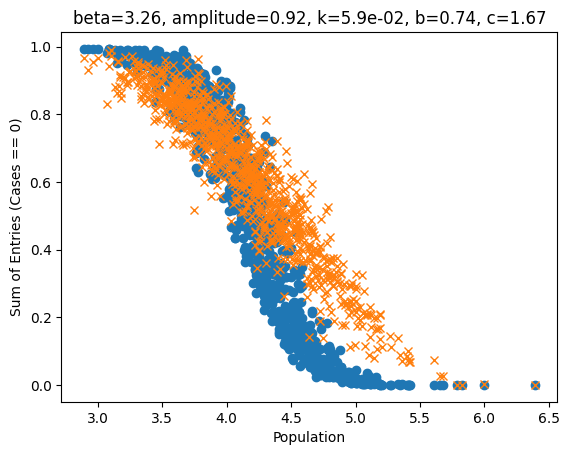

In [31]:
#Plot the proportion of weeks with no incidence case from the first sim, and from the data
ind = 0
plt.plot(np.log10(model.scenario.population), results_df.loc[ind]["prop_zero"], 'o')
plt.plot(np.log10(model.scenario.population), model.scenario.prop_zero, 'x')
plt.xlabel('Population')
plt.ylabel('Sum of Entries (Cases == 0)')
plt.title('beta=%.2f, amplitude=%.2f, k=%.1e, b=%.2f, c=%.2f' % (results_df.loc[ind]["beta"], results_df.loc[ind]["amplitude"], results_df.loc[ind]["k"], results_df.loc[ind]["b"], results_df.loc[ind]["c"]))
plt.show()

In [34]:
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D

# 1. Define fitting functions for mean and variance
def logistic(x, x0, k):
    # Logistic function bounded between 0 and 1, transitions from 1 to 0 as x increases
    return 1 / (1 + np.exp(k * (x - x0)))

def fit_mean_var(x, y):
    # Fit a logistic to the mean
    # Initial guess: midpoint at median(x), width=1
    p0 = [np.median(x), 1.0]
    bounds = ([-np.inf, 0.01], [np.inf, 10.0])
    popt_mean, _ = curve_fit(logistic, x, y, p0=p0, bounds=bounds, maxfev=10000)
    return popt_mean

# 3. Define similarity metric (sum of squared differences of mean and variance fits)
def similarity_metric(mean_data, mean_sim):
    # Evaluate both curves on a common grid
    x_grid = np.linspace(2.5, 6.5, 200)
    data_curve = logistic(x_grid, *mean_data)
    sim_curve = logistic(x_grid, *mean_sim)
    # Similarity: sum of squared differences between the curves
    mean_diff = np.sum((sim_curve - data_curve) ** 2)
    return mean_diff

similarity = []

for i in results_df.index:
    # Plot observed and simulated data
    logpop_obs = np.log10(model.scenario.population)
    prop_zero_obs = model.scenario.prop_zero
    logpop_sim = np.log10(model.scenario.population)
    prop_zero_sim = results_df.loc[i]['prop_zero']

    # Fit to observed
    popt_obs = fit_mean_var(logpop_obs, prop_zero_obs)
    popt_sim = fit_mean_var(logpop_sim, prop_zero_sim)
    # Similarity metric
    similarity.append(similarity_metric(popt_obs, popt_sim))
results_df["similarity_CCS"] = similarity




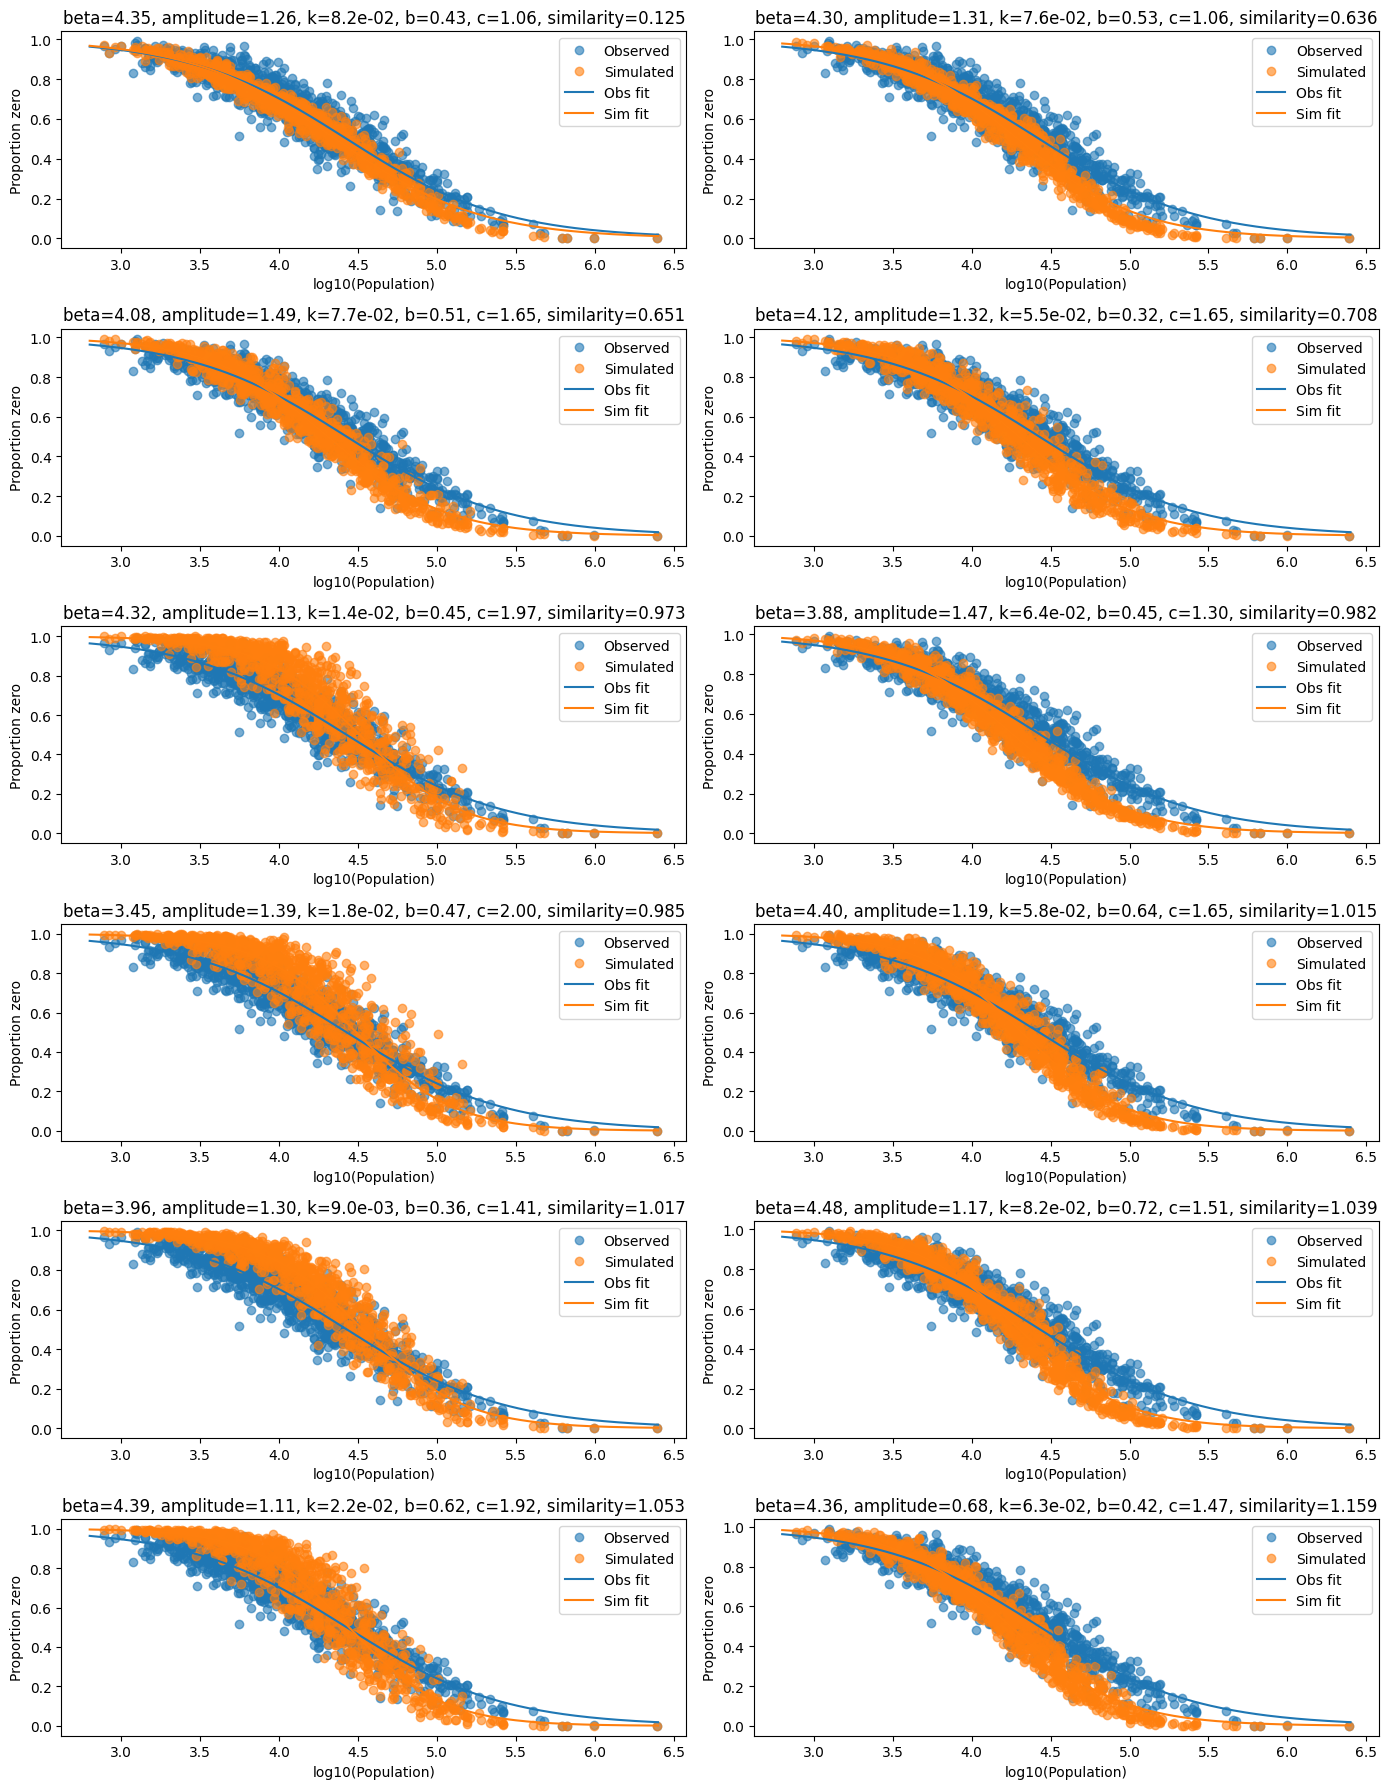

In [35]:
fig, axes = plt.subplots(6, 2, figsize=(14, 18))
axes = axes.flatten()

ranked_params = results_df.sort_values('similarity_CCS', ascending=True).reset_index(drop=True)
ranked_params[0:20]

for idx in range(12):
    # Get the parameter set with the idx-th lowest similarity
    beta_best, amp_best, k_best, b_best, c_best = ranked_params.loc[idx, ['beta', 'amplitude', 'k', 'b', 'c']]
    sim_score = ranked_params.loc[idx, 'similarity_CCS']
    prop_zero_sim = ranked_params.loc[idx, 'prop_zero']

    # Fit logistic to simulation
    popt_sim = fit_mean_var(np.log10(model.scenario.population), prop_zero_sim)
    # Fit logistic to observed (reuse from above)
    popt_obs = fit_mean_var(np.log10(model.scenario.population), model.scenario.prop_zero)

    xfit = np.linspace(2.8, 6.4, 200)
    axes[idx].plot(np.log10(model.scenario.population), model.scenario.prop_zero, 'o', label='Observed', alpha=0.6)
    axes[idx].plot(np.log10(model.scenario.population), prop_zero_sim, 'o', label='Simulated', alpha=0.6)
    axes[idx].plot(xfit, logistic(xfit, *popt_obs), '-', label='Obs fit', color='C0')
    axes[idx].plot(xfit, logistic(xfit, *popt_sim), '-', label='Sim fit', color='C1')
    axes[idx].set_title(f"beta={beta_best:.2f}, amplitude={amp_best:.2f}, k={k_best:.1e}, b={b_best:.2f}, c={c_best:.2f}, similarity={sim_score:.3f}")
    axes[idx].set_xlabel("log10(Population)")
    axes[idx].set_ylabel("Proportion zero")
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [36]:
def pad_data(x):
    """
    Pad data to the next power of 2
    """
    nx = len(x) # number of samples
    nx2 = (2**np.ceil(np.log(nx)/np.log(2))).astype(int) # next power of 2
    x2 = np.zeros(nx2, dtype=x.dtype) # pad to next power of 2
    offset = (nx2-nx)//2 # offset
    x2[offset:(offset+nx)] = x # copy
    return x2

def log_transform(x, debug=1):
    """
    Log transform for case data
    """ 
    # add one and take log
    x = np.log(x+1)
    # set mean=0 and std=1
    m = np.mean(x)
    s = np.std(x)
    x = (x - m)/s
    return x


def calc_Ws(cases):
    # transform case data
    log_cases = pad_data(log_transform(cases))

    # setup and execute wavelet transform
    # https://pywavelets.readthedocs.io/en/latest/ref/cwt.html#morlet-wavelet
    wavelet = pywt.ContinuousWavelet('cmor2-1')

    dt = 1 # 2 weeks
    widths = np.logspace(np.log10(1), np.log10(7*52), int(7*52))
    [cwt, frequencies] = pywt.cwt(log_cases, widths, wavelet, dt)

    # Number of time steps in padded time series
    nt = len(cases)
    # trim matrix
    offset = (cwt.shape[1] - nt) // 2
    cwt = cwt[:, offset:offset + nt]

    return cwt, frequencies


In [69]:
def wavelet_phase_diff(data, distances, ref_cwt):


    if isinstance(data, pd.DataFrame):
        x = np.zeros(len(data))
        y = np.zeros(len(data))
        y2 = np.zeros(len(data))
        for i, row in data.iterrows():
            if distances[i] > 30:
                continue
            cwt, frequencies = calc_Ws(row["cases"].flatten())
            diff = ref_cwt*np.conj(cwt)
            ind = np.where(np.logical_and(frequencies < 1/(1.5 * 52), frequencies > 1 / (3 * 52))) #Frequencies around 2 year periods.
            diff1 = diff[ind[0], :]
            x[i] = distances[i]
            y[i] = np.angle(np.mean(diff1))
            ind2 = np.where(np.logical_and(frequencies < 1/(0.75 * 52), frequencies > 1 / (1.25 * 52))) #Frequencies around 1 year periods
            diff2 = diff[ind2[0], :]
            y2[i] = np.angle(np.mean(diff2))
            
    elif isinstance(data, np.ndarray):
        # initialize output arrays
        x = np.zeros(data.shape[1])
        y = np.zeros(data.shape[1])
        y2 = np.zeros(data.shape[1])
        for i in range(data.shape[1]):
            if distances[i] > 30:
                continue
            cwt, frequencies = calc_Ws(data[:, i].flatten())
            diff = ref_cwt*np.conj(cwt)
            ind = np.where(np.logical_and(frequencies < 1/(1.5 * 52), frequencies > 1 / (3 * 52)))
            diff1 = diff[ind[0], :]
            x[i] = distances[i]
            y[i] = np.angle(np.mean(diff1))
            ind2 = np.where(np.logical_and(frequencies < 1/(0.75 * 52), frequencies > 1 / (1.25 * 52)))
            diff2 = diff[ind2[0], :]
            y2[i] = np.angle(np.mean(diff2))
    return x, y, y2

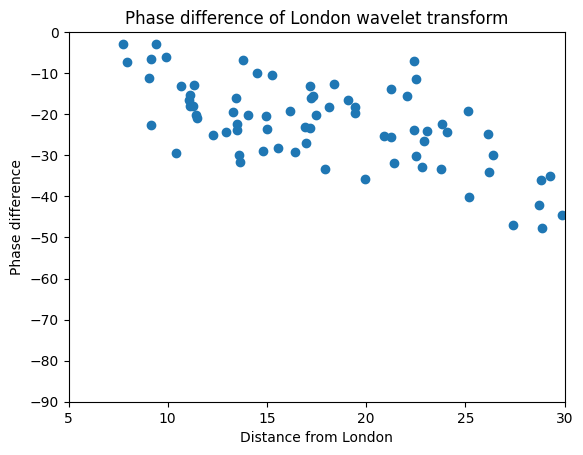

In [ ]:
# Get the cases for London from EWdata
distances = np.load(os.path.join("..","..","..", "data", "EnglandWalesdistances.npy"))


EWdata = pd.DataFrame([{"name": placename,
         "population": place.population[0],
         "latitude": place.latitude,
         "longitude": place.longitude} for placename, place in engwal.places.items()])

EWdata["cases"] = EWdata["name"].apply(lambda name: engwal.places[name].cases)

# Calculate distances between all locations
locations = np.array([[place.latitude, place.longitude] for place in engwal.places.values()])

# Calculate wavelet transforms and phase differences from London
london_idx = EWdata[EWdata["name"].str.contains("London", case=False)].index[0]
london_cases = EWdata[EWdata["name"].str.contains("London", case=False)]["cases"].iloc[0]

ref_cwt, frequencies = calc_Ws(np.array(london_cases.flatten()))
distances_from_london = distances[london_idx, :]

x_data, y_data, y2_data = wavelet_phase_diff(  EWdata, distances_from_london, ref_cwt)
# Plot phase differences
plt.plot(x_data, -y_data*180/np.pi, 'o')
plt.xlim(5, 30)
plt.ylim(-90, 0)
plt.xlabel("Distance from London")
plt.ylabel("Phase difference")
plt.title("Phase difference of London wavelet transform")
plt.show()

In [70]:
results_df["wavelet_y"] = None
results_df["wavelet_y2"] = None

for sim_idx in range(weekly_incidence.shape[0]):
    cases = weekly_incidence[sim_idx, :, :]
    # Get London cases for this simulation
    london_cases_sim = cases[:, london_idx].flatten()
    ref_cwt_sim, frequencies_sim = calc_Ws(np.array(london_cases_sim[520:]).flatten())
    

    x_sim, y_sim, y2_sim = wavelet_phase_diff(cases[520:, :], distances_from_london, ref_cwt_sim)
    results_df.at[sim_idx, "wavelet_y"] = y_sim
    results_df.at[sim_idx, "wavelet_y2"] = y2_sim
    np.save('outputs/EW_analysis_results.npy', results_df)

/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_13324/1269829586.py:21: RuntimeWarning: invalid value encountered in divide
  x = (x - m)/s


In [64]:
cases[520:, :].shape[1]

954

In [68]:
y.shape

(954,)

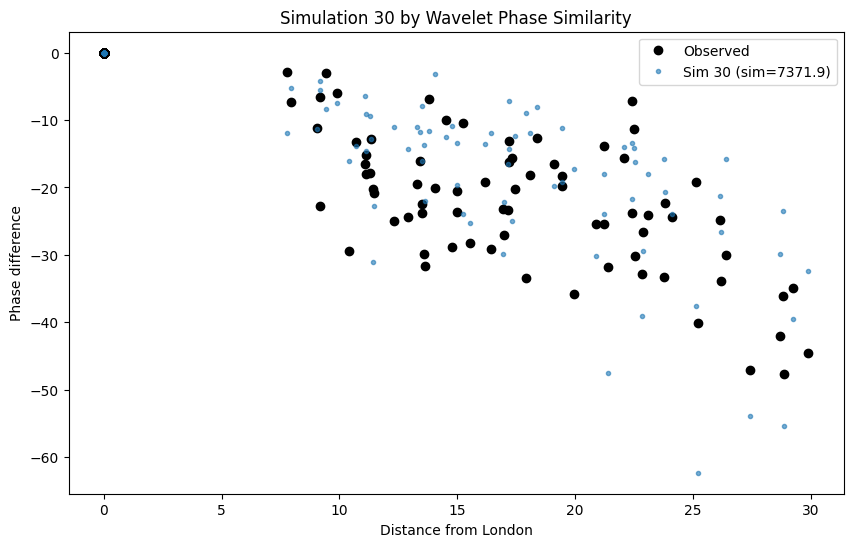

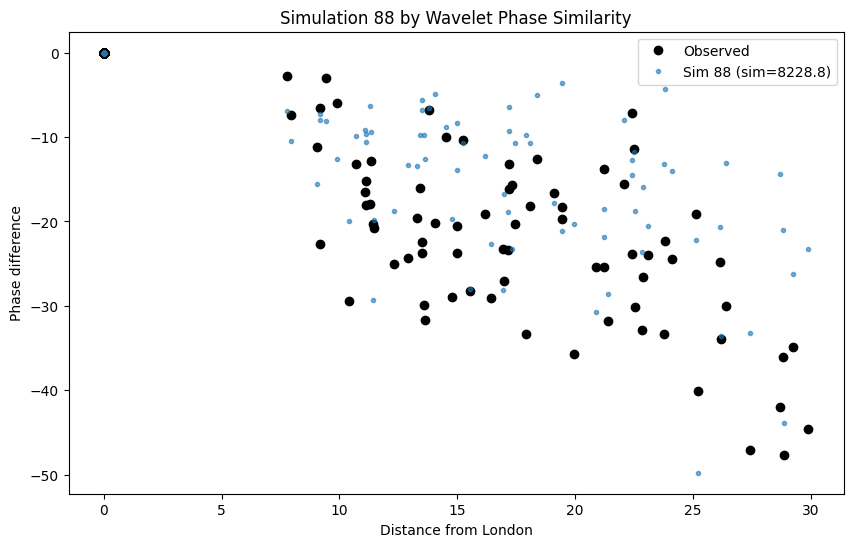

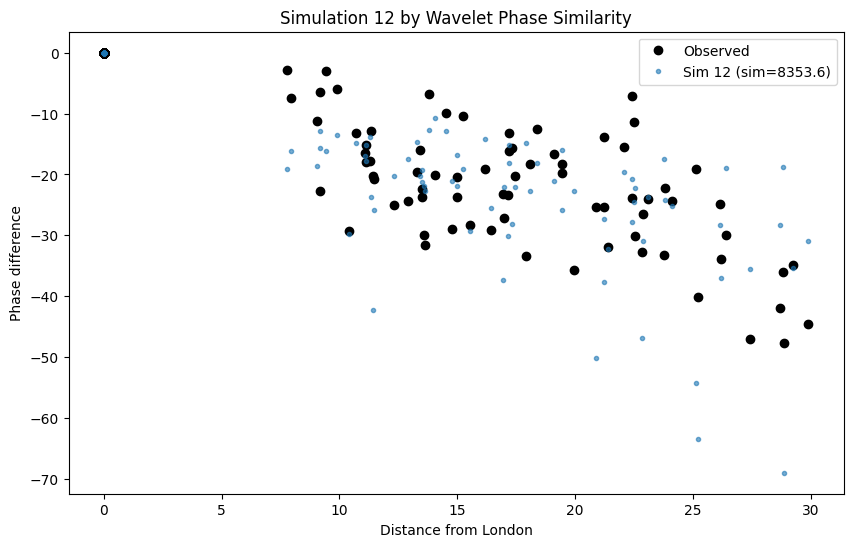

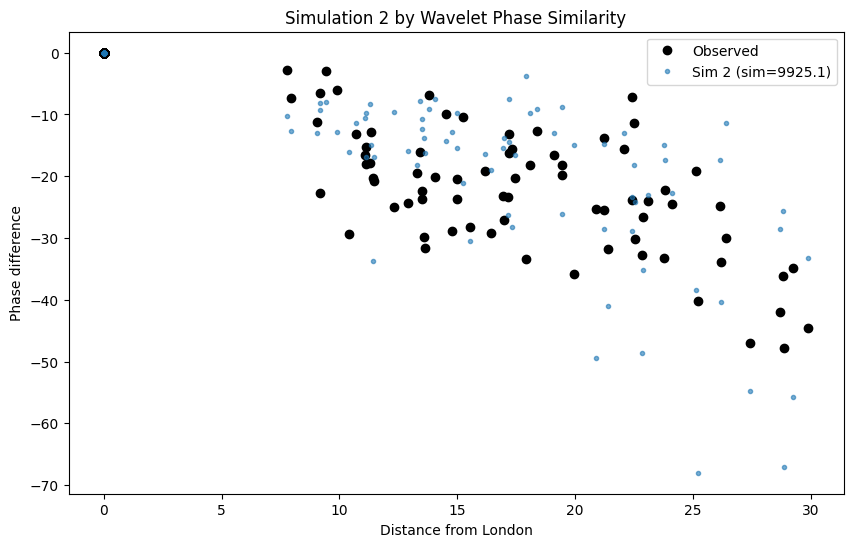

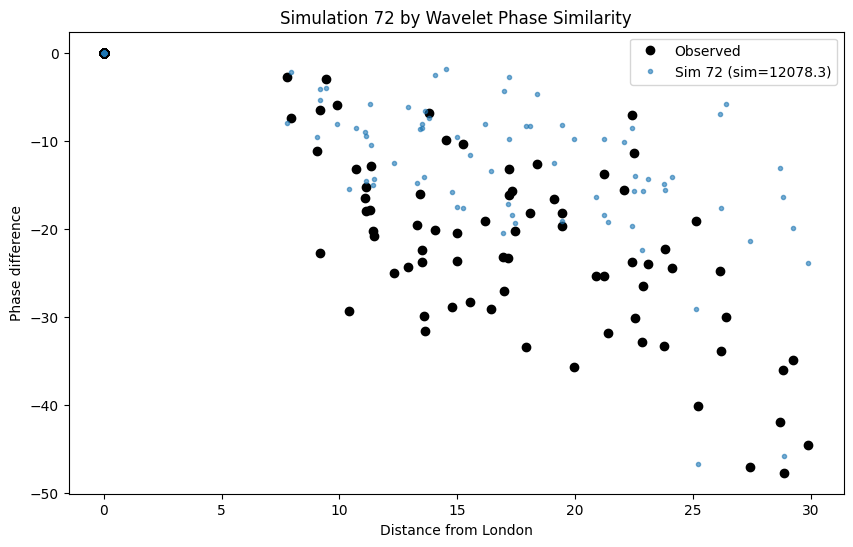

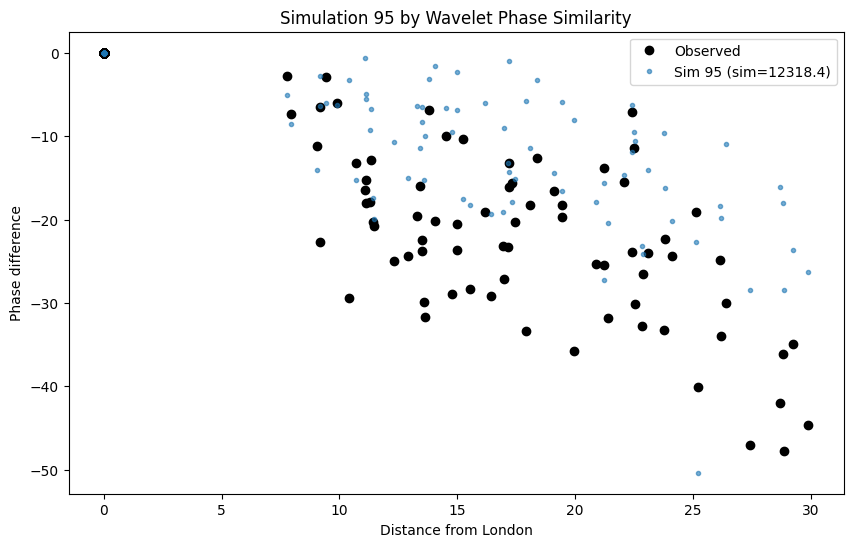

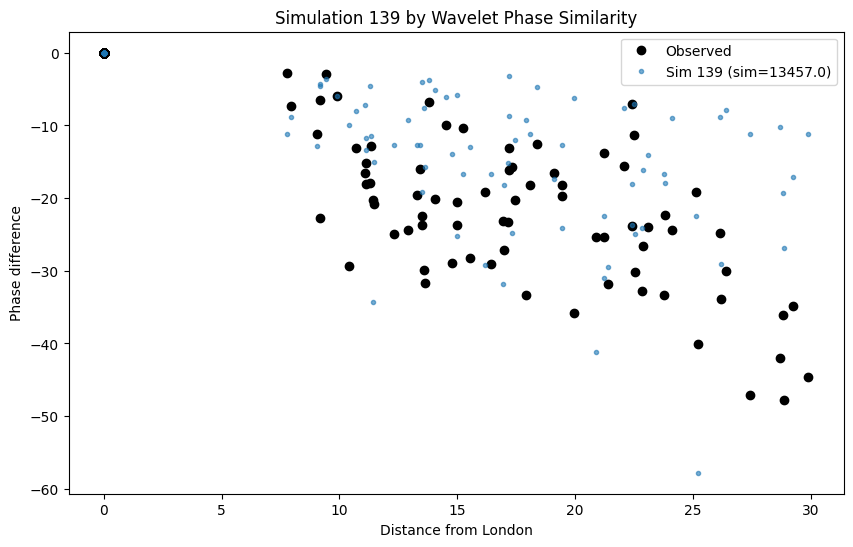

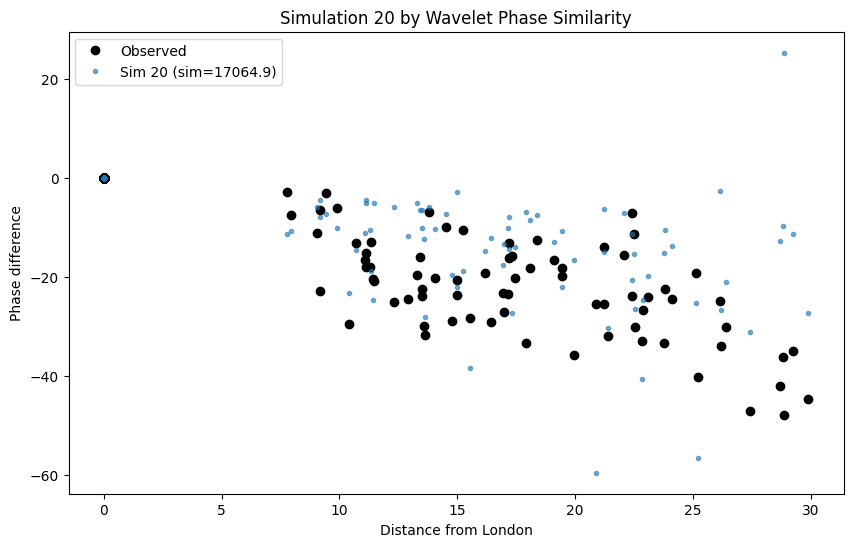

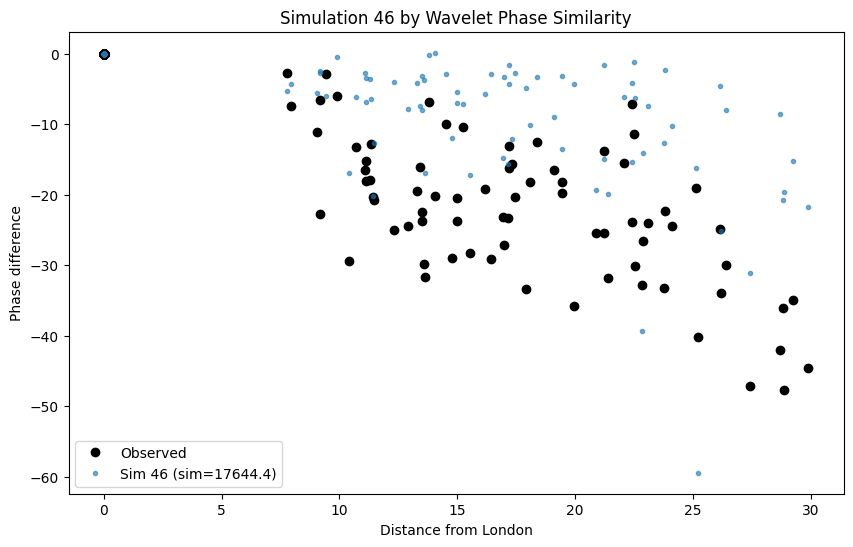

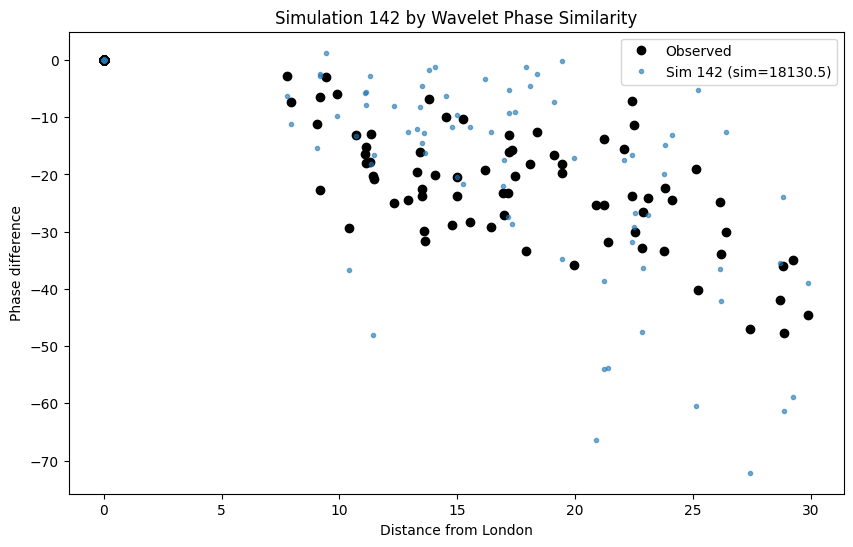

In [79]:
from scipy.stats import linregress

#
mask_data = (x_data > 0) & (y_data != 0)
slope_data, intercept_data, _, _, _ = linregress(x_data[mask_data], -180/np.pi*y_data[mask_data])
# Compute variance of observed phase differences
var_data = np.var(-180/np.pi*y_data[mask_data])

# Define similarity metric as sum of squared differences between observed and simulated phase differences for each city in the mask
def phase_similarity(y_obs, y_sim, mask):
    # Only compare where both masks are valid
    return np.sum(((-180/np.pi)*y_obs[mask] - (-180/np.pi)*y_sim[mask])**2)

sim_phase_diffs = []
for idx, row in results_df.iterrows():
    y_sim = row['wavelet_y']
    if isinstance(y_sim, np.ndarray):
        mask_sim = (x_data > 0) & (y_sim != 0) & (y_data != 0)
        if np.any(mask_sim):
            sim_phase_diffs.append(phase_similarity(y_data, y_sim, mask_sim))
        else:
            sim_phase_diffs.append(np.nan)
    else:
        sim_phase_diffs.append(np.nan)

results_df['wavelet_phase_similarity'] = sim_phase_diffs

# Find the 10 simulations with the lowest phase similarity (best match)
top10_idx = np.argsort(results_df['wavelet_phase_similarity'].values)[:10]

for i, idx in enumerate(top10_idx):
    plt.figure(figsize=(10, 6))
    y_sim = results_df.loc[idx, 'wavelet_y']
    if isinstance(y_sim, np.ndarray):
        plt.plot(x_data, -180/np.pi*y_data, 'ko', label='Observed')
        plt.plot(x_data, -180/np.pi*y_sim, '.', alpha=0.6, label=f'Sim {idx} (sim={results_df.loc[idx, "wavelet_phase_similarity"]:.1f})')
        plt.xlabel('Distance from London')
        plt.ylabel('Phase difference')
        plt.title(f'Simulation {idx} by Wavelet Phase Similarity')
        plt.legend()
        plt.show()

# sim_slopes = []
# sim_vars = []
# for idx, row in results_df.iterrows():
#     y_sim = row['wavelet_y']
#     if isinstance(y_sim, np.ndarray):
#         mask_sim = (x_data > 0) & (y_sim != 0)
#         if np.any(mask_sim):
#             slope_sim, _, _, _, _ = linregress(x_data[mask_sim], -180/np.pi*y_sim[mask_sim])
#             var_sim = np.var(-180/np.pi*y_sim[mask_sim])
#         else:
#             slope_sim = np.nan
#             var_sim = np.nan
#     else:
#         slope_sim = np.nan
#         var_sim = np.nan
#     sim_slopes.append(slope_sim)
#     sim_vars.append(var_sim)

# results_df['wavelet_slope'] = sim_slopes
# results_df['wavelet_var'] = sim_vars

# # Find the 10 sims with slope and variance closest to the observed
# distance_metric = np.abs(results_df['wavelet_slope'] - slope_data) + np.abs(results_df['wavelet_var'] - var_data)
# closest_idx = np.argsort(distance_metric)[:10]

# for i, idx in enumerate(closest_idx):
#     plt.figure(figsize=(10, 6))
#     y_sim = results_df.loc[idx, 'wavelet_y']
#     slope_sim = results_df.loc[idx, 'wavelet_slope']
#     var_sim = results_df.loc[idx, 'wavelet_var']
#     mask_sim = (x_data > 0) & (y_sim != 0)
#     intercept_sim = 0
#     if np.any(mask_sim):
#         _, intercept_sim, _, _, _ = linregress(x_data[mask_sim], -180/np.pi*y_sim[mask_sim])
#         plt.plot(x_data, -180/np.pi*y_data, 'ko', label='Observed')
#         plt.plot(x_data, slope_data * x_data + intercept_data, 'k--', label='Obs fit')
#         plt.plot(x_data, -180/np.pi*y_sim, '.', alpha=0.5, label=f'Sim {idx} (slope={slope_sim:.2f}, var={var_sim:.2f})')
#         plt.plot(x_data, slope_sim * x_data + intercept_sim, '--', alpha=0.5)
#     plt.xlabel('Distance from London')
#     plt.ylabel('Phase difference')
#     plt.legend()
#     plt.title(f'Wavelet phase: obs vs. sim {idx} (slope={slope_sim:.2f}, var={var_sim:.2f})')
#     plt.show()

Best combined similarity simulation index: 30
Parameters:
beta         4.076528
amplitude    1.493013
k            0.076838
b             0.51179
c            1.651364
Name: 30, dtype: object
CCS similarity rank: 3.0
Wavelet phase similarity rank: 1.0


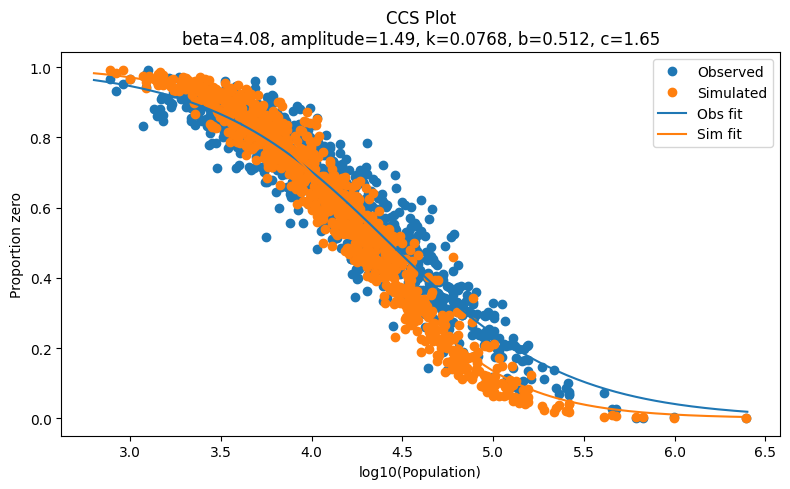

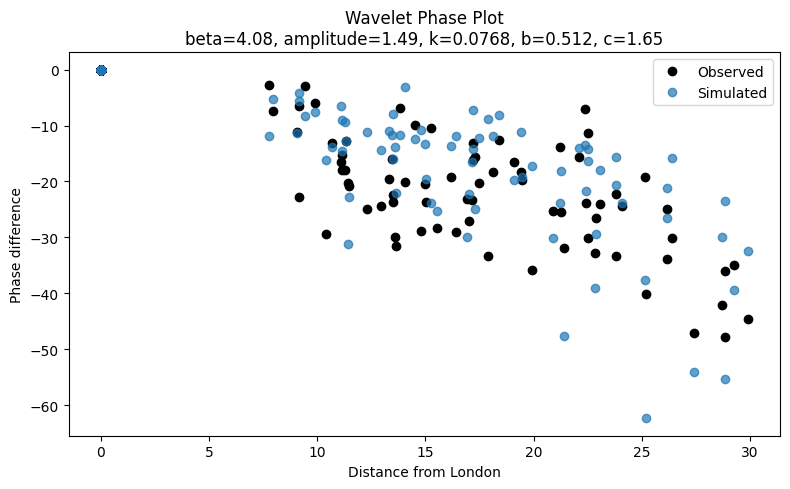

In [82]:
# Rank the simulations by CCS similarity (lower is better)
ccs_ranks = results_df['similarity_CCS'].rank(method='min', ascending=True)
# Rank the simulations by wavelet phase similarity (lower is better)
phase_ranks = results_df['wavelet_phase_similarity'].rank(method='min', ascending=True)

# Combine the ranks (sum of ranks, lower is better)
combined_rank = ccs_ranks + phase_ranks

# Find the index of the simulation with the lowest combined rank
best_idx = combined_rank.idxmin()

print(f"Best combined similarity simulation index: {best_idx}")
print("Parameters:")
print(results_df.loc[best_idx, ['beta', 'amplitude', 'k', 'b', 'c']])
print("CCS similarity rank:", ccs_ranks[best_idx])
print("Wavelet phase similarity rank:", phase_ranks[best_idx])

# Plot CCS (proportion zero vs log10(population))
plt.figure(figsize=(8, 5))
plt.plot(np.log10(model.scenario.population), model.scenario.prop_zero, 'o', label='Observed')
plt.plot(np.log10(model.scenario.population), results_df.loc[best_idx, 'prop_zero'], 'o', label='Simulated')
xfit = np.linspace(2.8, 6.4, 200)
popt_obs = fit_mean_var(np.log10(model.scenario.population), model.scenario.prop_zero)
popt_sim = fit_mean_var(np.log10(model.scenario.population), results_df.loc[best_idx, 'prop_zero'])
plt.plot(xfit, logistic(xfit, *popt_obs), '-', color='C0', label='Obs fit')
plt.plot(xfit, logistic(xfit, *popt_sim), '-', color='C1', label='Sim fit')
plt.xlabel('log10(Population)')
plt.ylabel('Proportion zero')
plt.title('CCS Plot\n' + ', '.join([f'{k}={results_df.loc[best_idx, k]:.3g}' for k in ['beta','amplitude','k','b','c']]))
plt.legend()
plt.tight_layout()
plt.show()

# Plot wavelet phase difference
y_sim = results_df.loc[best_idx, 'wavelet_y']
plt.figure(figsize=(8, 5))
plt.plot(x_data, -180/np.pi*y_data, 'ko', label='Observed')
if isinstance(y_sim, np.ndarray):
    plt.plot(x_data, -180/np.pi*y_sim, 'o', alpha=0.7, label='Simulated')
plt.xlabel('Distance from London')
plt.ylabel('Phase difference')
plt.title('Wavelet Phase Plot\n' + ', '.join([f'{k}={results_df.loc[best_idx, k]:.3g}' for k in ['beta','amplitude','k','b','c']]))
plt.legend()
plt.tight_layout()
plt.show()